In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scprinter as scp
import scanpy as sc
import snapatac2 as snap
import anndata as ad
import pychromvar as pc
import torch
torch.manual_seed(42)
from pyjaspar import jaspardb
import os
import json
import seaborn as sns
from umap import UMAP
import sys
sys.path.append('/data1/normantm/multiome_collab')
import multiome as mo
from importlib import reload
reload(mo)

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']
plt.rcParams['font.size'] = 12
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['pdf.fonttype'] = 42

In [ ]:
expt = mo.MultiomeExperiment.load("/data1/normantm/multiome_collab/RPE1/intermediate_files/RPE1_multiomeTFs.pkl")

In [ ]:
macs3_sgrna = snap.tl.macs3(expt.atac, groupby = 'joint_id_ntc', inplace = False)
merged_peaks = snap.tl.merge_peaks(macs3_sgrna, snap.genome.hg38)
mtx = snap.pp.make_peak_matrix(expt.atac, use_rep = merged_peaks.to_pandas().Peaks)
ntc_peaklist = merged_peaks.to_pandas().query("NTC").Peaks.tolist()
bg_idx = mtx.var_names.get_indexer(ntc_peaklist)

In [5]:
scp.chromvar.sample_bg_peaks(mtx, scp.genome.hg38, bg_set = bg_idx)

Fetching GC content:   0%|          | 0/439303 [00:00<?, ?it/s]

Sampling nearest neighbors


array([[193048, 321186, 373097, ...,  63388, 193348, 269206],
       [389082, 333987, 170346, ..., 122167, 200687, 149344],
       [ 32725, 160606, 280911, ...,  61425, 293169, 150026],
       ...,
       [ 45606, 439300, 378285, ..., 241285, 229514, 148252],
       [285894, 233882, 176397, ...,  94151,  25613, 195533],
       [285894, 233882, 176397, ..., 263760, 374880, 429337]])

In [6]:
pc.add_peak_seq(mtx, genome_file='/data1/normantm/eli/seq2gex/data/genome/genome.fa', delimiter=":|-")
jdb_obj = jaspardb(release='JASPAR2026')
motifs = jdb_obj.fetch_motifs(collection='CORE', tax_group=['vertebrates'])
pc.match_motif(mtx, motifs=motifs, background = 'subject')
chromvar_out = scp.chromvar.compute_deviations(mtx)

100%|██████████| 439303/439303 [07:51<00:00, 931.81it/s]


Computing expectation reads per cell and peak...


Processing chunks:   0%|          | 0/3 [00:00<?, ?it/s]

Processing background peaks:   0%|          | 0/50 [00:00<?, ?it/s]

Processing background peaks:   0%|          | 0/50 [00:00<?, ?it/s]

Processing background peaks:   0%|          | 0/50 [00:00<?, ?it/s]

/data1/normantm/eli/mamba/miniforge3/envs/scprinter/lib/python3.11/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.


In [7]:
chromvar_out.write_h5ad("RPE1_chromvar_raw.h5ad")

... storing 'guide_target' as categorical
... storing 'identity' as categorical
... storing 'LB_identity' as categorical
... storing 'joint_id' as categorical
... storing 'joint_id_ntc' as categorical
... storing 'gem_group' as categorical


In [8]:
import anndata as ad
prgm_guides = expt.all_singlets_assigned.joint_id_ntc.value_counts().to_frame().query("count >= 20").index
adata = ad.read_h5ad("RPE1_chromvar_raw.h5ad")
adata = adata[adata.obs.joint_id_ntc.isin(prgm_guides)]
sc.pp.pca(adata, n_comps=50, random_state = 42)

/data1/normantm/eli/mamba/miniforge3/envs/scprinter/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:379: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.


/data1/normantm/multiome_collab/multiome.py:1295: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


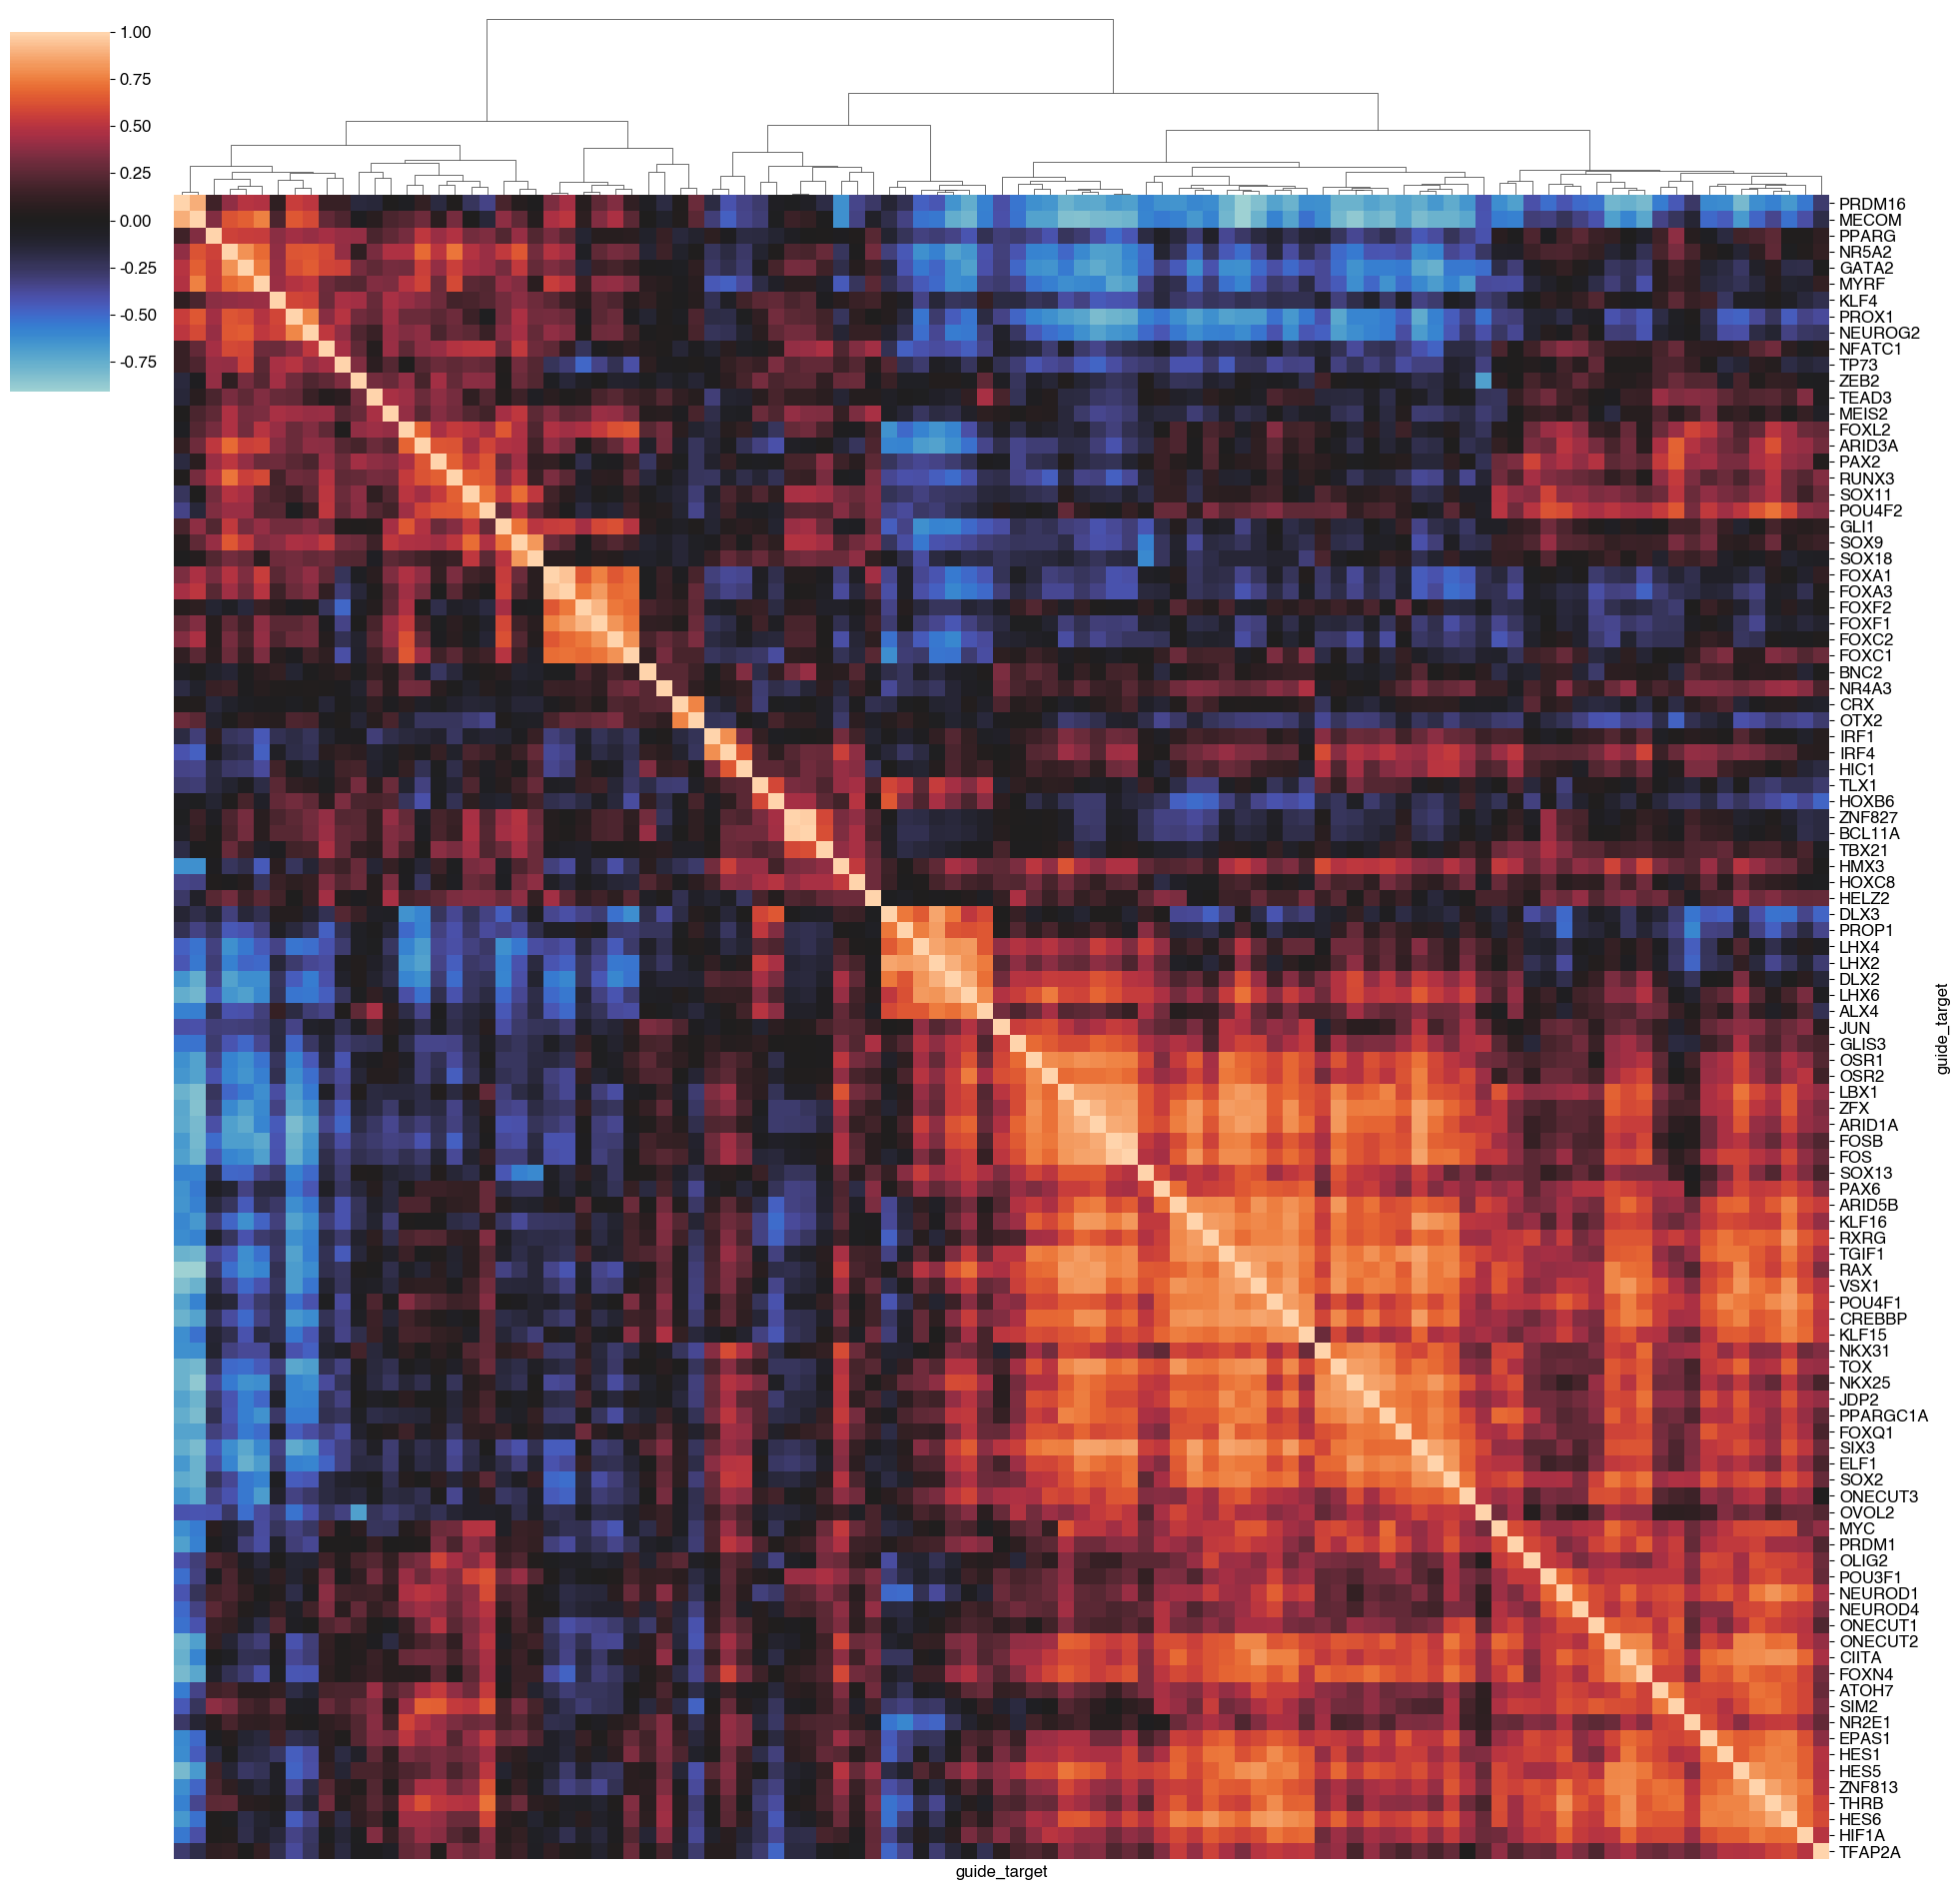

In [9]:
mo.cluster(adata, figsize = (20,20), yticklabels = 1)

In [29]:
df_chromvar = adata.to_df().join(adata.obs.guide_target)
ntc_mean, ntc_std = df_chromvar.query("guide_target == 'NTC'").drop("guide_target", axis = 1).mean(), df_chromvar.query("guide_target == 'NTC'").drop("guide_target", axis = 1).std()
df_chromvar_norm = (df_chromvar.drop('guide_target', axis = 1) - ntc_mean) / ntc_std
adata_norm = ad.AnnData(df_chromvar_norm, obs = adata.obs)

/data1/normantm/multiome_collab/multiome.py:1295: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


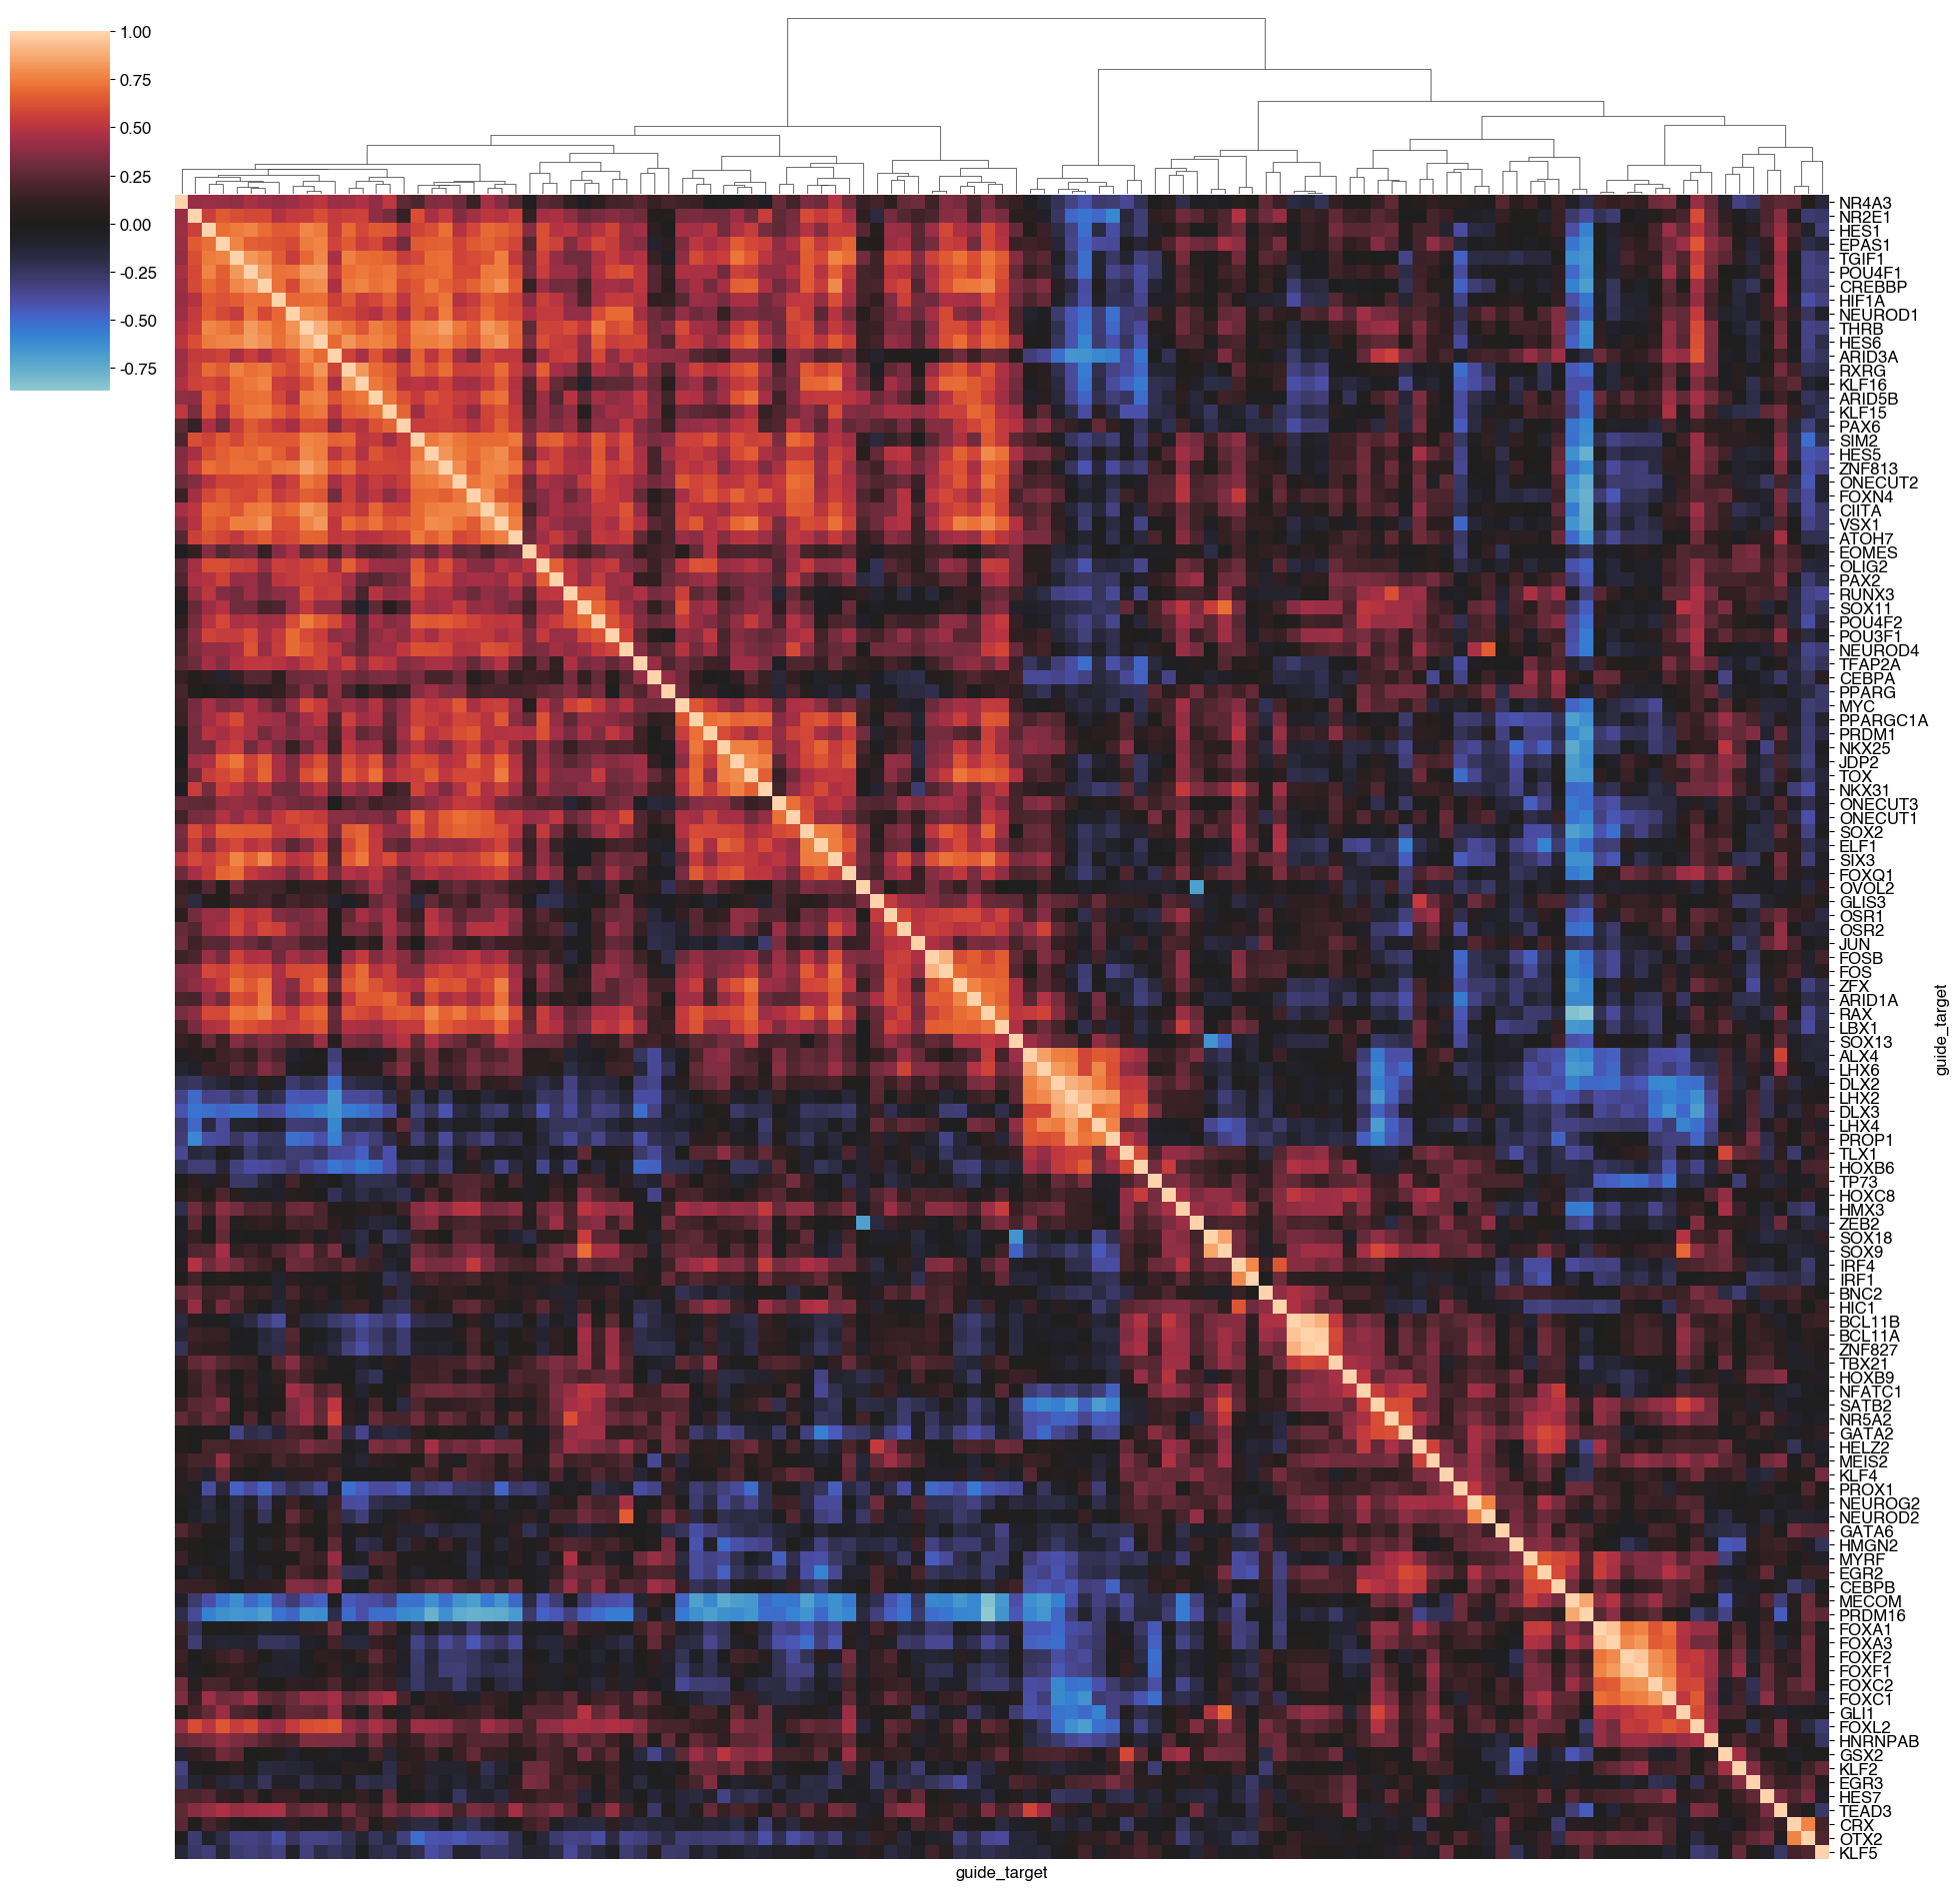

In [31]:
sc.pp.pca(adata_norm, n_comps=50, random_state = 42)
mo.cluster(adata_norm, figsize = (20,20), yticklabels = 1)

In [32]:
peak_motifs = pd.DataFrame(mtx.varm['motif_match'], index = mtx.var_names, columns = mtx.uns['motif_name'])

In [33]:
adata = sc.read('RPE1_chromvar_raw.h5ad')

df_chromvar = adata.to_df().join(adata.obs.guide_target)
ntc_mean, ntc_std = df_chromvar.query("guide_target == 'NTC'").drop("guide_target", axis = 1).mean(), df_chromvar.query("guide_target == 'NTC'").drop("guide_target", axis = 1).std()
df_chromvar_norm = (df_chromvar.drop('guide_target', axis = 1) - ntc_mean) / ntc_std
adata = ad.AnnData(X = df_chromvar_norm, obs = pd.DataFrame(df_chromvar.guide_target,index = df_chromvar_norm.index), var = pd.DataFrame(index = df_chromvar_norm.columns))

adata.write_h5ad('RPE1_chromvar_znorm.h5ad')

In [36]:
adata.obs['single_cell'] = True
adata.var['in_matrix'] = True
adata.obs['guide_target'] = adata.obs.guide_target.map(lambda x: 'NKX25' if x == 'NKX2-5' else 'NKX31' if x == 'NKX3-1' else x)
df = mo.get_differential_genes(adata, key = 'guide_target', control_key = "guide_target == 'NTC'", return_all = True)
df.to_csv("intermediate_files/RPE1_chromvar_motifs_differential.csv", index = False)

Done.
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
groupby: index in @key_barcodes (key = guide_target)
[Parallel(n_jobs=16)]: Done   1 tasks      | elapsed:   10.7s
[Parallel(n_jobs=16)]: Done   2 tasks      | elapsed:   10.9s
[Parallel(n_jobs=16)]: Done   3 tasks      | elapsed:   11.3s
[Parallel(n_jobs=16)]: Done   4 tasks      | elapsed:   11.5s
[Parallel(n_jobs=16)]: Done   5 tasks      | elapsed:   11.5s
[Parallel(n_jobs=16)]: Done   6 tasks      | elapsed:   11.6s
[Parallel(n_jobs=16)]: Done   7 tasks      | elapsed:   12.0s
[Parallel(n_jobs=16)]: Done   8 tasks      | elapsed:   12.1s
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:   12.3s
[Parallel(n_jobs=16)]: Done  10 tasks      | elapsed:   12.6s
[Parallel(n_jobs=16)]: Done  11 tasks      | elapsed:   12.8s
[Parallel(n_jobs=16)]: Done  12 tasks      | elapsed:   13.3s
[Parallel(n_jobs=16)]: Done  13 tasks      | elapsed:   13.4s
[Parallel(n_jobs=16)]: Done  14 tasks      | elapsed:   13

In [37]:
df_ont = df.query("q < 0.1").copy()
df_ont['gene'] = df_ont.gene.str.split(".").str[-1]
df_ont.sort_values("q", inplace = True)
df_ont['gene'] = df_ont.gene.str.upper()
df_ont = df_ont.drop_duplicates(["gene", "guide_target"], keep = 'first')
df_ont = df_ont.query("gene.isin(@df.guide_target)").copy()
df_ont['gene'] = pd.Categorical(df_ont.gene, ordered=True, categories = pd.Series(df_ont.gene.unique()).sort_values())
df_ont.guide_target = pd.Categorical(df_ont.guide_target, ordered=True, categories = pd.Series(df_ont.guide_target.unique()).sort_values())
df_ont['logq'] = df_ont.q.map(lambda x: np.clip(-np.log10(x),1,10))
df_ont['z'] = np.clip(df_ont.z, -1, 1)

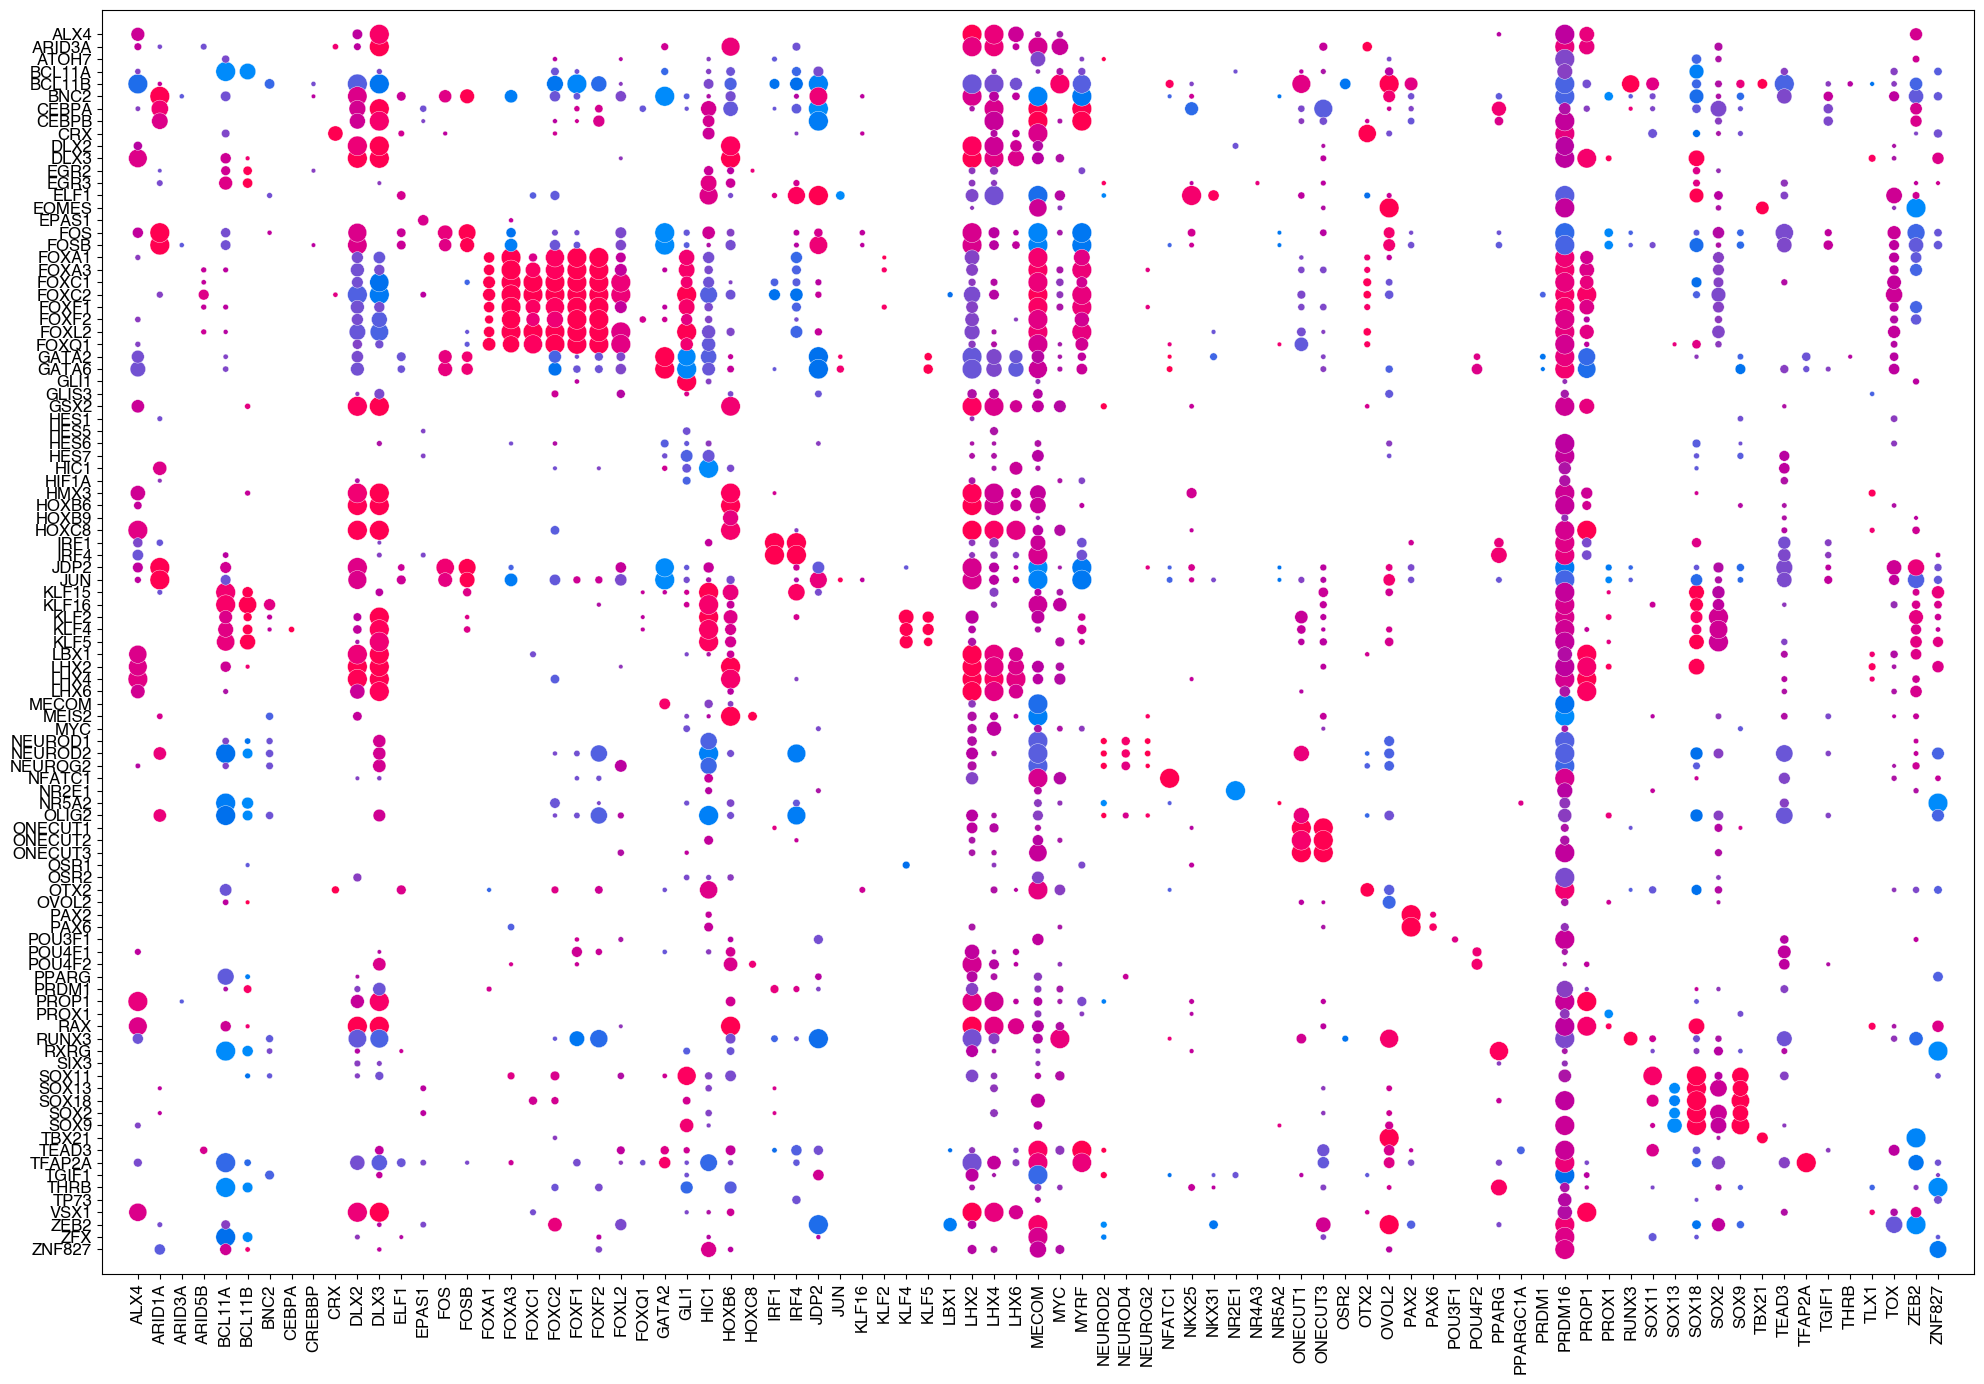

In [38]:
from shap.plots.colors import red_blue
plt.figure(figsize = (20,14))
sns.scatterplot(data = df_ont, x = 'guide_target', y = 'gene', hue = 'z', size = 'logq', sizes = (10, 200), palette = red_blue, legend = None)
plt.xticks(rotation = 90)
plt.margins(x=0.02, y=0.02)
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.tight_layout()
plt.show()